# Practice Lab E: Neural Networks from Scratch

**Area:** ml-connection · **Related lessons/concepts:** L45–L47; Quiz 12; Homework 12

**You will be able to:**


In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Two-blob data

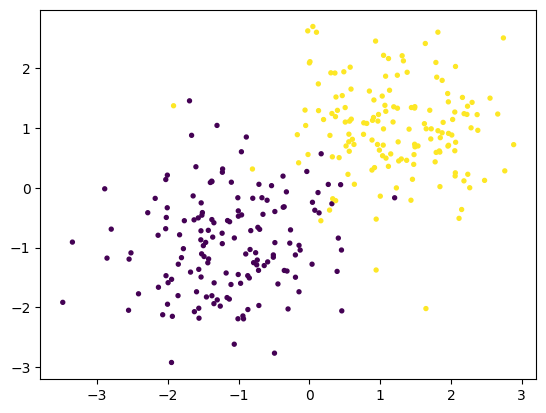

In [2]:
rng=np.random.default_rng(0)
X=np.r_[rng.normal([-1,-1],0.8,(150,2)),rng.normal([1.2,1],0.8,(150,2))]; y=np.r_[np.zeros(150),np.ones(150)]
plt.scatter(*X.T,c=y,s=8); plt.show()

## 2. Logistic regression (a single perceptron with sigmoid + log-loss)

In [3]:
sig=lambda z:1/(1+np.exp(-z))
w=np.zeros(2); b=0.
for _ in range(2000):
    p=sig(X@w+b); w-=0.3*X.T@(p-y)/len(y); b-=0.3*np.mean(p-y)
p=sig(X@w+b); print("accuracy",np.mean((p>.5)==y),"log-loss",-np.mean(y*np.log(p)+(1-y)*np.log(1-p)))

accuracy 0.9633333333333334 log-loss 0.09090266520176314


## 3. XOR-like data needs a hidden layer

In [4]:
Xx=rng.uniform(-1,1,(400,2)); yx=((Xx[:,0]*Xx[:,1])>0).astype(float)
def train(X,y,H=6,lr=0.5,n=6000,seed=0):
    r=np.random.default_rng(seed); W1=r.normal(0,1,(2,H)); b1=np.zeros(H); W2=r.normal(0,1,(H,1)); b2=np.zeros(1)
    for _ in range(n):
        A=np.tanh(X@W1+b1); P=sig(A@W2+b2)[:,0]
        d2=(P-y)[:,None]/len(y); dW2=A.T@d2; db2=d2.sum(0)
        d1=(d2@W2.T)*(1-A**2); dW1=X.T@d1; db1=d1.sum(0)
        W1-=lr*dW1; b1-=lr*db1; W2-=lr*dW2; b2-=lr*db2
    return W1,b1,W2,b2
def predict(params,X): W1,b1,W2,b2=params; return sig(np.tanh(X@W1+b1)@W2+b2)[:,0]
params=train(Xx,yx); print("2-layer accuracy",np.mean((predict(params,Xx)>.5)==yx))
wl=np.zeros(2); bl=0.
for _ in range(2000): pp=sig(Xx@wl+bl); wl-=0.3*Xx.T@(pp-yx)/len(yx); bl-=0.3*np.mean(pp-yx)
print("logistic accuracy",np.mean((sig(Xx@wl+bl)>.5)==yx))

2-layer accuracy 0.995
logistic accuracy 0.4975


## 4. Decision boundary

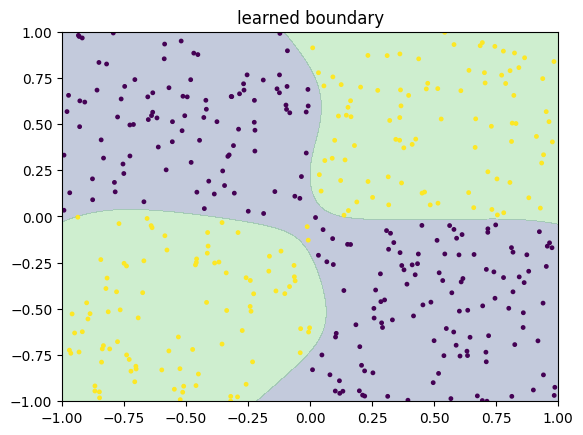

In [5]:
g1,g2=np.meshgrid(np.linspace(-1,1,150),np.linspace(-1,1,150)); Z=predict(params,np.c_[g1.ravel(),g2.ravel()]).reshape(g1.shape)
plt.contourf(g1,g2,Z,levels=[0,.5,1],alpha=.3); plt.scatter(*Xx.T,c=yx,s=6); plt.title("learned boundary"); plt.show()

## 5. Gradient check on one weight

In [6]:
W1,b1,W2,b2=params; x0=Xx[:1]; y0=yx[:1]
def L(W1_): 
    P=sig(np.tanh(x0@W1_+b1)@W2+b2)[0,0]; return -(y0[0]*np.log(P)+(1-y0[0])*np.log(1-P))
A=np.tanh(x0@W1+b1); P=sig(A@W2+b2)[0,0]; d2=(P-y0[0]); d1=(d2*W2[:,0])*(1-A[0]**2); analytic=np.outer(x0[0],d1)
e=1e-6; Wp=W1.copy(); Wp[0,0]+=e; Wm=W1.copy(); Wm[0,0]-=e
print(analytic[0,0], (L(Wp)-L(Wm))/(2*e))

-1.8312228563480382e-08 -1.8318680110628694e-08


## Exercises

**Exercise 1.** How many hidden units are needed to reach >95% accuracy on the XOR-like data? Try H = 1, 2, 4.

In [7]:
# your code here

**Exercise 2.** Show logistic regression on the XOR-like data stays near 50%.

In [8]:
# your code here

## Solutions
*(Try the exercises first!)*

In [9]:
# Solution 1
print({H:round(float(np.mean((predict(train(Xx,yx,H=H),Xx)>.5)==yx)),3) for H in (1,2,4)})

{1: 0.67, 2: 0.745, 4: 0.995}


In [10]:
# Solution 2
assert abs(np.mean((sig(Xx@wl+bl)>.5)==yx)-0.5)<0.15